# RSM8341 Assignment 1: Asset Pricing
## Team 10: Harsh, Samir, Alex, Wesley & Gino

In [3]:
import pandas as pd
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt

In [9]:
stock_prices = pd.read_csv('prices.csv')
market_prices = pd.read_csv('market.csv')
treasury_rates = pd.read_csv('DGS10.csv', na_values='.')

## Part 1: From Prices to Returns

In [10]:
stock_prices['Date'] = pd.to_datetime(stock_prices['Date'])
market_prices['Date'] = pd.to_datetime(market_prices['Date'])
treasury_rates['Date'] = pd.to_datetime(treasury_rates['observation_date'])

treasury_rates = treasury_rates.drop(columns=['observation_date'])

cutoff = stock_prices['Date'].max() - pd.DateOffset(years=10)
stock_prices = stock_prices[stock_prices['Date'] >= cutoff].reset_index(drop=True)

common_dates = stock_prices['Date']
market_prices = market_prices[market_prices['Date'].isin(common_dates)].reset_index(drop=True)
treasury_rates = treasury_rates[treasury_rates['Date'].isin(common_dates)].reset_index(drop=True)

display(stock_prices.head())
display(market_prices.head())
display(treasury_rates.head())

,Date,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,...,WTW,WY,WYNN,XEL,XOM,XYL,YUM,ZBH,ZBRA,ZTS
0,2015-03-04,38.679150,28.706537,39.771614,NaN,38.854362,18.811941,77.067551,77.629997,47.521145,...,107.532234,23.238997,121.084457,25.248211,56.308872,31.467518,47.678905,106.658325,91.029999,42.945576
1,2015-03-05,38.881775,28.230852,37.521389,NaN,39.209774,18.989443,78.033951,78.620003,47.561821,...,108.143448,23.144056,121.241493,25.503759,56.024681,31.370514,47.940876,107.035538,91.160004,43.159248
2,2015-03-06,38.246311,28.273281,36.716324,NaN,38.432858,18.976765,76.864090,77.550003,47.138695,...,106.875664,22.398127,119.496986,24.569178,55.307724,31.009026,47.131145,104.493889,89.629997,42.527561
3,2015-03-09,38.439720,28.393879,36.650341,NaN,38.705601,19.179623,76.965813,77.930000,47.569962,...,107.622734,22.743965,115.868446,24.883141,55.004173,31.079567,47.297848,105.032761,89.400002,43.001328
4,2015-03-10,37.417477,27.806528,36.848297,NaN,38.160099,18.954576,74.651497,76.010002,46.544689,...,106.649300,22.540529,112.963898,24.941561,54.422886,30.594639,46.369045,103.739487,87.800003,42.453228


,Date,^GSPC
0,2015-03-04,2098.530029
1,2015-03-05,2101.040039
2,2015-03-06,2071.260010
3,2015-03-09,2079.429932
4,2015-03-10,2044.160034


,DGS10,Date
0,2.12,2015-03-04
1,2.11,2015-03-05
2,2.24,2015-03-06
3,2.20,2015-03-09
4,2.14,2015-03-10


In [11]:
display(market_prices['^GSPC'].isna().sum())
display(treasury_rates['DGS10'].isna().sum())

np.int64(0)

np.int64(18)

In [12]:
# 3. Apply forward fill to handle market holiday gaps
treasury_rates['DGS10'] = treasury_rates['DGS10'].ffill()
display(treasury_rates)
display(treasury_rates.isna().sum())

,DGS10,Date
0,2.12,2015-03-04
1,2.11,2015-03-05
2,2.24,2015-03-06
3,2.20,2015-03-09
4,2.14,2015-03-10
...,...,...
2511,4.25,2025-02-26
2512,4.29,2025-02-27
2513,4.24,2025-02-28
2514,4.16,2025-03-03


,0
DGS10,0
Date,0


In [13]:
# Extract unique dates as sets
stock_dates = set(stock_prices['Date'])
market_dates = set(market_prices['Date'])
rf_dates = set(treasury_rates['Date'])

# 1. Check if they are identical
all_match = (stock_dates == market_dates == rf_dates)
print(f"Do all dates match across all three files? {all_match}")

# 2. Find specific discrepancies if all_match is False
if not all_match:
    print(f"Dates in Market but not in Stocks: {len(market_dates - stock_dates)}")
    print(f"Dates in Stocks but not in Treasury: {len(stock_dates - rf_dates)}")

Do all dates match across all three files? True


### Task A) Computing Daily Log Returns

In [14]:
print('Total number of stocks:', len(stock_prices.columns.to_list()[1:]))
print('Stocks with > 0 missing values:', len(stock_prices.isna().sum()[stock_prices.isna().sum() > 0]))

Total number of stocks: 503
Stocks with > 0 missing values: 31


In [15]:
threshold = len(stock_prices)
stock_prices = stock_prices.dropna(axis=1, thresh=threshold)
stock_prices.shape

print('Stocks with after adjusting for threshold:', len(stock_prices.columns.to_list())-1)

Stocks with after adjusting for threshold: 472


In [16]:
price_cols = stock_prices.columns[1:]  # all price columns except Date

stock_prices[price_cols] = stock_prices[price_cols].apply(pd.to_numeric, errors='coerce')

log_returns = np.log(stock_prices[price_cols] / stock_prices[price_cols].shift(1))

log_returns.columns = [f"{col}" for col in price_cols]

daily_returns = pd.concat([stock_prices[['Date']], log_returns], axis=1)

daily_stock_returns = daily_returns.iloc[1:].reset_index(drop=True)

In [17]:
market_prices['MRKT_Return'] = np.log(market_prices['^GSPC'] / market_prices['^GSPC'].shift(1))
daily_market_returns = market_prices[['Date', 'MRKT_Return']].iloc[1:].reset_index(drop=True)
daily_market_returns

,Date,MRKT_Return
0,2015-03-05,0.001195
1,2015-03-06,-0.014275
2,2015-03-09,0.003937
3,2015-03-10,-0.017107
4,2015-03-11,-0.001920
...,...,...
2510,2025-02-26,0.000136
2511,2025-02-27,-0.015992
2512,2025-02-28,0.015730
2513,2025-03-03,-0.017753


In [18]:
daily_stock_returns

,Date,A,AAPL,ABBV,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WTW,WY,WYNN,XEL,XOM,XYL,YUM,ZBH,ZBRA,ZTS
0,2015-03-05,0.005225,-0.016709,-0.058242,0.009106,0.009391,0.012462,0.012672,0.000856,0.008460,...,0.005668,-0.004094,0.001296,0.010071,-0.005060,-0.003087,0.005479,0.003530,0.001427,0.004963
1,2015-03-06,-0.016479,0.001502,-0.021690,-0.020013,-0.000668,-0.015105,-0.013703,-0.008936,-0.026247,...,-0.011792,-0.032761,-0.014493,-0.037333,-0.012880,-0.011590,-0.017034,-0.024032,-0.016926,-0.014744
2,2015-03-09,0.005044,0.004256,-0.001799,0.007072,0.010633,0.001323,0.004888,0.009107,0.003022,...,0.006966,0.015323,-0.030836,0.012698,-0.005504,0.002272,0.003531,0.005144,-0.002569,0.011079
3,2015-03-10,-0.026953,-0.020903,0.005387,-0.014194,-0.011803,-0.030531,-0.024946,-0.021789,-0.018932,...,-0.009086,-0.008985,-0.025387,0.002345,-0.010624,-0.015726,-0.019833,-0.012389,-0.018059,-0.012828
4,2015-03-11,0.005400,-0.018400,0.013872,0.002811,0.015926,-0.013721,0.000000,0.001572,-0.000439,...,0.013075,0.004503,-0.022489,-0.009117,-0.002853,-0.003464,-0.017878,0.006214,0.002275,0.006761
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2510,2025-02-26,0.002159,-0.027412,-0.005551,0.001030,-0.008671,-0.012755,-0.004317,-0.006695,-0.037188,...,0.010521,-0.012327,0.000769,-0.006837,-0.002464,0.003430,-0.017340,-0.022896,0.029026,-0.021229
2511,2025-02-27,-0.056524,-0.012813,0.009852,-0.000662,0.027854,-0.004139,-0.009810,-0.043190,-0.008336,...,-0.003127,0.007681,-0.032464,0.011227,0.006284,0.002177,0.014482,-0.008327,-0.026902,-0.000061
2512,2025-02-28,0.006588,0.018951,0.019370,0.015628,0.008756,-0.023733,0.003129,0.027364,0.013008,...,0.012920,0.001330,0.012732,0.018760,0.010656,0.016252,0.017157,0.002592,0.012938,0.013606
2513,2025-03-03,-0.012508,-0.015880,0.011653,0.015887,0.000753,-0.010123,0.004913,-0.006673,-0.013223,...,0.002088,0.041964,-0.004376,-0.002778,-0.032592,-0.008517,0.003575,0.010110,-0.026405,0.019481


### Task B) Annualize Expected Excess Returns

In [19]:
treasury_rates['RF_Rate'] = np.log(1 + treasury_rates['DGS10']/100) / 252
treasury_rates.drop(columns='DGS10', inplace=True)
daily_treasury_rates = treasury_rates.copy()
daily_treasury_rates.head()

,Date,RF_Rate
0,2015-03-04,0.000083
1,2015-03-05,0.000083
2,2015-03-06,0.000088
3,2015-03-09,0.000086
4,2015-03-10,0.000084


In [20]:
mean_stock_returns = daily_stock_returns[price_cols].mean()
annualized_excess_returns = 252 * mean_stock_returns - 252 * daily_treasury_rates['RF_Rate'].mean()
annualized_excess_returns

,0
A,0.091108
AAPL,0.186201
ABBV,0.140793
ABT,0.101831
ACGL,0.134045
...,...
XYL,0.115194
YUM,0.095449
ZBH,-0.027398
ZBRA,0.093940


In [21]:
daily_cov = daily_stock_returns[price_cols].cov()
annualized_cov = 252 * daily_cov
annualized_cov

,A,AAPL,ABBV,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,...,WTW,WY,WYNN,XEL,XOM,XYL,YUM,ZBH,ZBRA,ZTS
A,0.071053,0.035979,0.025718,0.035982,0.026281,0.036982,0.043904,0.045105,0.025993,0.032048,...,0.026856,0.040906,0.044843,0.016422,0.023874,0.038501,0.025002,0.031326,0.051134,0.038631
AAPL,0.035979,0.080883,0.021141,0.030205,0.025429,0.038773,0.054523,0.051108,0.023709,0.033805,...,0.025740,0.040790,0.048278,0.017527,0.024382,0.034405,0.026253,0.027801,0.052695,0.035187
ABBV,0.025718,0.021141,0.071062,0.027341,0.020596,0.021728,0.024550,0.023402,0.018676,0.022857,...,0.019011,0.026355,0.027618,0.013887,0.021643,0.021130,0.017255,0.025242,0.025095,0.026888
ABT,0.035982,0.030205,0.027341,0.056182,0.023860,0.030700,0.035512,0.032457,0.021001,0.029614,...,0.024408,0.033366,0.026829,0.020347,0.017392,0.029861,0.022482,0.030415,0.035951,0.033752
ACGL,0.026281,0.025429,0.020596,0.023860,0.072284,0.030776,0.025875,0.031622,0.031043,0.033679,...,0.031568,0.043913,0.047059,0.022047,0.033230,0.036154,0.026797,0.031066,0.033097,0.025010
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
XYL,0.038501,0.034405,0.021130,0.029861,0.036154,0.036691,0.036641,0.044614,0.030851,0.035915,...,0.030497,0.048309,0.051621,0.019985,0.032135,0.071134,0.028594,0.032352,0.047799,0.031950
YUM,0.025002,0.026253,0.017255,0.022482,0.026797,0.027317,0.028707,0.030438,0.022160,0.027047,...,0.024113,0.037188,0.040908,0.017530,0.022804,0.028594,0.057256,0.027508,0.031888,0.026994
ZBH,0.031326,0.027801,0.025242,0.030415,0.031066,0.030950,0.030027,0.035130,0.026233,0.028522,...,0.025534,0.041126,0.052612,0.015687,0.029923,0.032352,0.027508,0.073542,0.036201,0.029175
ZBRA,0.051134,0.052695,0.025095,0.035951,0.033097,0.046082,0.056161,0.063717,0.033553,0.040328,...,0.031369,0.055493,0.067262,0.013898,0.033231,0.047799,0.031888,0.036201,0.159615,0.044707


### Task C) Stock Analysis - Returns, Volatility, Correlations

In [22]:
# Align Market and Treasury to match the Stock returns length
aligned_market = daily_market_returns.set_index('Date')
aligned_treasury = daily_treasury_rates.set_index('Date')
aligned_stocks = daily_stock_returns.set_index('Date')

common_idx = aligned_stocks.index.intersection(aligned_market.index).intersection(aligned_treasury.index)

stocks_final = aligned_stocks.loc[common_idx]
market_final = aligned_market.loc[common_idx, 'MRKT_Return']
rf_final = aligned_treasury.loc[common_idx, 'RF_Rate']

market_var = market_final.var()
beta_values = {}

for col in stocks_final.columns:
    # Covariance of stock i with market
    covariance = stocks_final[col].cov(market_final)
    beta_values[col] = covariance / market_var

stats_summary = pd.DataFrame({
    'Annualized_Return': (stocks_final.mean() - rf_final.mean()) * 252,
    'Annualized_Volatility': stocks_final.std() * np.sqrt(252),
    'Beta': pd.Series(beta_values),
    'Market_Correlation': stocks_final.corrwith(market_final)
})

stats_summary.head()

,Annualized_Return,Annualized_Volatility,Beta,Market_Correlation
A,0.091107,0.266558,1.011006,0.678724
AAPL,0.186199,0.284399,1.188014,0.747525
ABBV,0.140791,0.266574,0.664650,0.446176
ABT,0.101829,0.237028,0.835692,0.630924
ACGL,0.134043,0.268856,0.885733,0.589541


In [23]:
annualized_excess_returns = 252 * stocks_final.mean() - 252 * rf_final.mean()

In [24]:
# 1. Highest and Lowest Average (Excess) Returns
high_ret_ticker = stats_summary['Annualized_Return'].idxmax()
low_ret_ticker = stats_summary['Annualized_Return'].idxmin()

# 2. Highest Volatility (The "Riskiest" Stock)
high_vol_ticker = stats_summary['Annualized_Volatility'].idxmax()
low_vol_ticker = stats_summary['Annualized_Volatility'].idxmin()

# 3. Highest and Lowest Beta (Systematic Risk)
high_beta_ticker = stats_summary['Beta'].idxmax()
low_beta_ticker = stats_summary['Beta'].idxmin()

# 4. Highest and Lowest Correlation with the Market
high_corr_ticker = stats_summary['Market_Correlation'].idxmax()
low_corr_ticker = stats_summary['Market_Correlation'].idxmin()

# Create a display table for the anomalies
anomalies = pd.DataFrame({
    'Metric': [
        'Highest Avg Return', 'Lowest Avg Return',
        'Highest Volatility', 'Lowest Volatility',
        'Highest Beta', 'Lowest Beta',
        'Highest Market Corr', 'Lowest Market Corr'
    ],
    'Ticker': [
        high_ret_ticker, low_ret_ticker,
        high_vol_ticker, low_vol_ticker,
        high_beta_ticker, low_beta_ticker,
        high_corr_ticker, low_corr_ticker
    ],
    'Value': [
        stats_summary.loc[high_ret_ticker, 'Annualized_Return'],
        stats_summary.loc[low_ret_ticker, 'Annualized_Return'],
        stats_summary.loc[high_vol_ticker, 'Annualized_Volatility'],
        stats_summary.loc[low_vol_ticker, 'Annualized_Volatility'],
        stats_summary.loc[high_beta_ticker, 'Beta'],
        stats_summary.loc[low_beta_ticker, 'Beta'],
        stats_summary.loc[high_corr_ticker, 'Market_Correlation'],
        stats_summary.loc[low_corr_ticker, 'Market_Correlation']
    ]
})

display(anomalies)

,Metric,Ticker,Value
0,Highest Avg Return,NVDA,0.513098
1,Lowest Avg Return,WBA,-0.190867
2,Highest Volatility,ENPH,0.803022
3,Lowest Volatility,KO,0.179858
4,Highest Beta,CZR,1.877440
5,Lowest Beta,CPB,0.300551
6,Highest Market Corr,BLK,0.801904
7,Lowest Market Corr,NEM,0.196530


In [25]:
# --- 1. Identify the 5 Standout Stocks ---
# We map specific names to the index of the min/max of your calculated columns
selected_tickers = {
    "highest_avg_return": stats_summary['Annualized_Return'].idxmax(),
    "lowest_avg_return": stats_summary['Annualized_Return'].idxmin(),
    "highest_volatility": stats_summary['Annualized_Volatility'].idxmax(),
    "highest_beta": stats_summary['Beta'].idxmax(),
    "lowest_market_correlation": stats_summary['Market_Correlation'].idxmin(),
}

# --- 2. Build the Final Top 5 Table ---
# Extract the full rows from stats_summary for these 5 tickers
top5_table = stats_summary.loc[list(selected_tickers.values())].copy()

# Add the 'reason_flagged' column based on the dictionary keys
top5_table.insert(0, "reason_flagged", list(selected_tickers.keys()))

# Reset index to turn the Ticker (index) into a column and rename it
top5_table = top5_table.reset_index().rename(columns={"index": "Stock"})

# --- 3. Clean up and Reorder Columns ---
# This ensures the order matches your documentation requirements
top5_table = top5_table[
    [
        "Stock",
        "reason_flagged",
        "Annualized_Return",
        "Annualized_Volatility",
        "Beta",
        "Market_Correlation"
    ]
]

print("Five statistically standout stocks:")
display(top5_table)

Five statistically standout stocks:


,Stock,reason_flagged,Annualized_Return,Annualized_Volatility,Beta,Market_Correlation
0,NVDA,highest_avg_return,0.513098,0.489970,1.757470,0.641874
1,WBA,lowest_avg_return,-0.190867,0.352821,0.807143,0.409380
2,ENPH,highest_volatility,0.120149,0.803022,1.564800,0.348709
3,CZR,highest_beta,0.161589,0.599704,1.877440,0.560223
4,NEM,lowest_market_correlation,0.051270,0.360399,0.395805,0.196530


## Part 2: The Security Market Line (SML)
### Task A) Regression with Monthly Excess Returns

In [26]:
import statsmodels.api as sm

combined = daily_stock_returns.set_index('Date').copy()
combined['MRKT'] = daily_market_returns.set_index('Date')['MRKT_Return']
combined['RF'] = daily_treasury_rates.set_index('Date')['RF_Rate']

# Summing log returns by month
monthly_data = combined.resample('ME').sum()

# 2. Calculate Monthly Excess Returns
# Excess Return = Stock Monthly Return - Risk Free Monthly Return
monthly_excess_market = monthly_data['MRKT'] - monthly_data['RF']
monthly_excess_stocks = monthly_data.drop(columns=['MRKT', 'RF']).sub(monthly_data['RF'], axis=0)

# 3. Run CAPM Regressions
capm_results = []

# Prepare the independent variable (Market Excess Return) and add a constant for Alpha
X = sm.add_constant(monthly_excess_market)

for stock in monthly_excess_stocks.columns:
    y = monthly_excess_stocks[stock]

    # Run OLS: Ri - Rf = Alpha + Beta*(Rm - Rf)
    model = sm.OLS(y, X).fit()

    capm_results.append({
        'Ticker': stock,
        'Alpha': model.params['const'],
        'Beta': model.params[0], # The slope coefficient for market excess return
        'R_Squared': model.rsquared,
        'StdErr_Beta': model.bse[0]
    })

# Convert to DataFrame for reporting
capm_stats_df = pd.DataFrame(capm_results)

# Display the first few rows
display(capm_stats_df.head())

,Ticker,Alpha,Beta,R_Squared,StdErr_Beta
0,A,0.000183,1.160041,0.502786,0.105750
1,AAPL,0.007768,1.200960,0.455290,0.120419
2,ABBV,0.007293,0.683395,0.167226,0.139801
3,ABT,0.003111,0.836663,0.388525,0.096218
4,ACGL,0.006859,0.664039,0.171000,0.134029


### Task B) Representative Stocks

In [27]:
# Sort by Beta to find extremes and the median
sorted_beta = capm_stats_df.sort_values(by='Beta')

# Representative Picks
low_beta_stock = sorted_beta.iloc[0]          # The absolute lowest Beta
high_beta_stock = sorted_beta.iloc[-1]         # The absolute highest Beta
mid_beta_stock = sorted_beta.iloc[len(sorted_beta)//2] # The median Beta

# Combine into a summary for comparison
representative_stocks = pd.DataFrame([low_beta_stock, mid_beta_stock, high_beta_stock])
representative_stocks.index = ['Low Beta', 'Mid-Range', 'High Beta']

display(representative_stocks[['Ticker','Alpha', 'Beta', 'R_Squared', 'StdErr_Beta']])

,Ticker,Alpha,Beta,R_Squared,StdErr_Beta
Low Beta,HRL,-0.001325,0.175378,0.017449,0.120641
Mid-Range,FTNT,0.014179,1.041443,0.206494,0.187147
High Beta,APA,-0.029114,2.902182,0.292448,0.413815


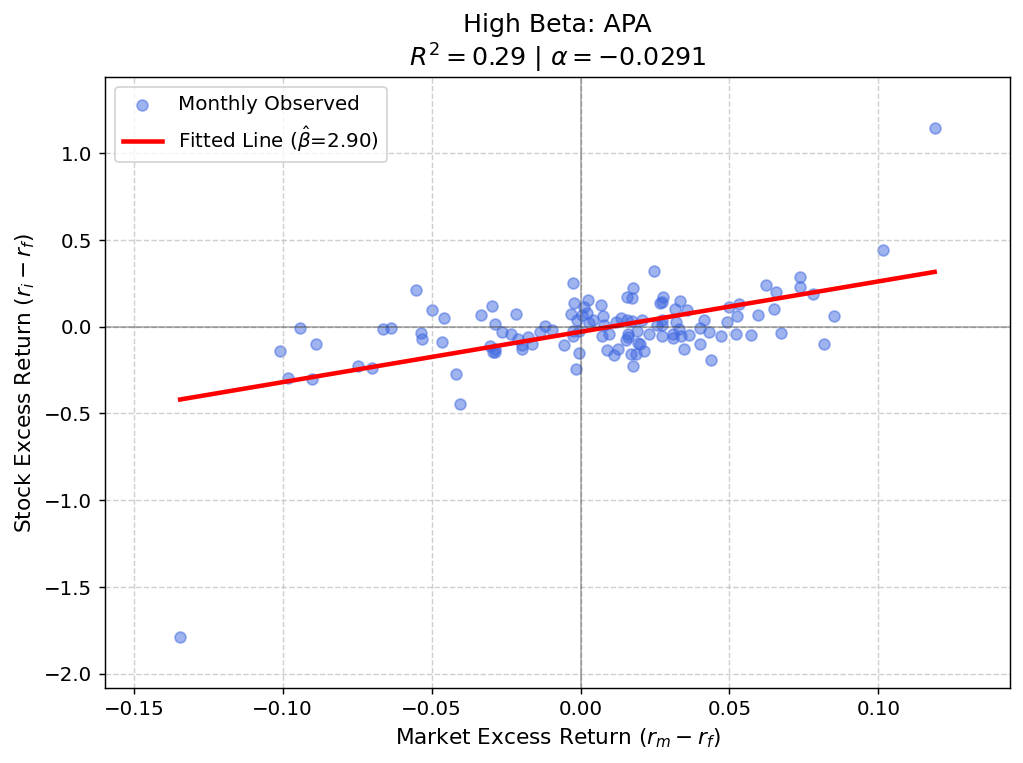

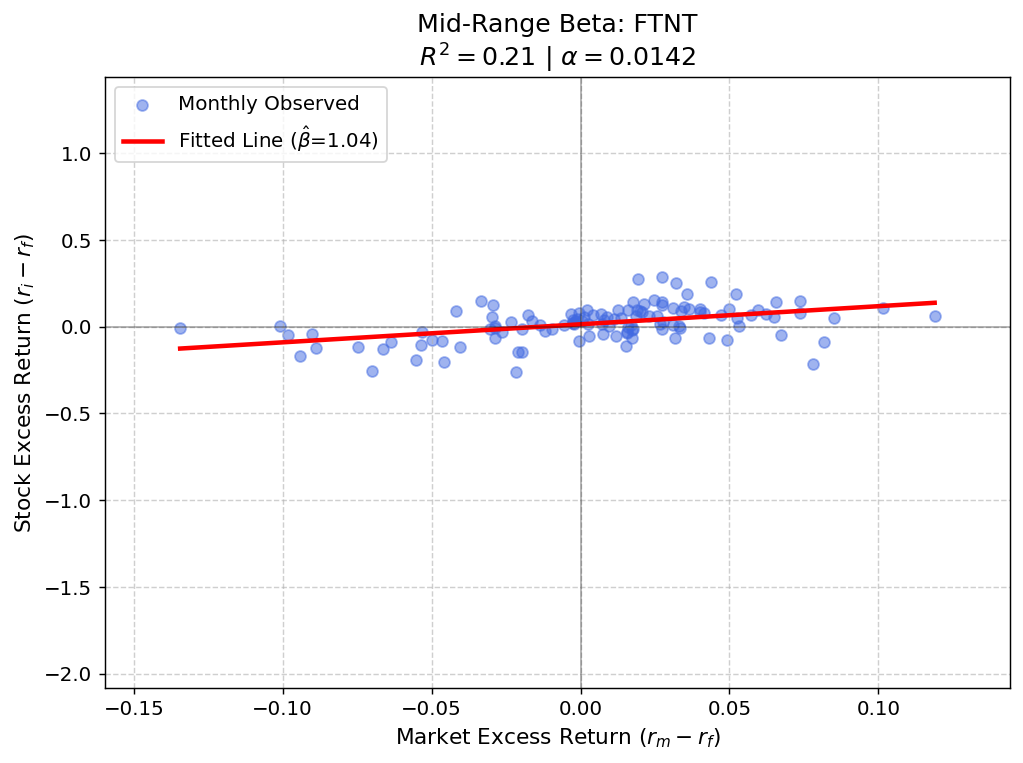

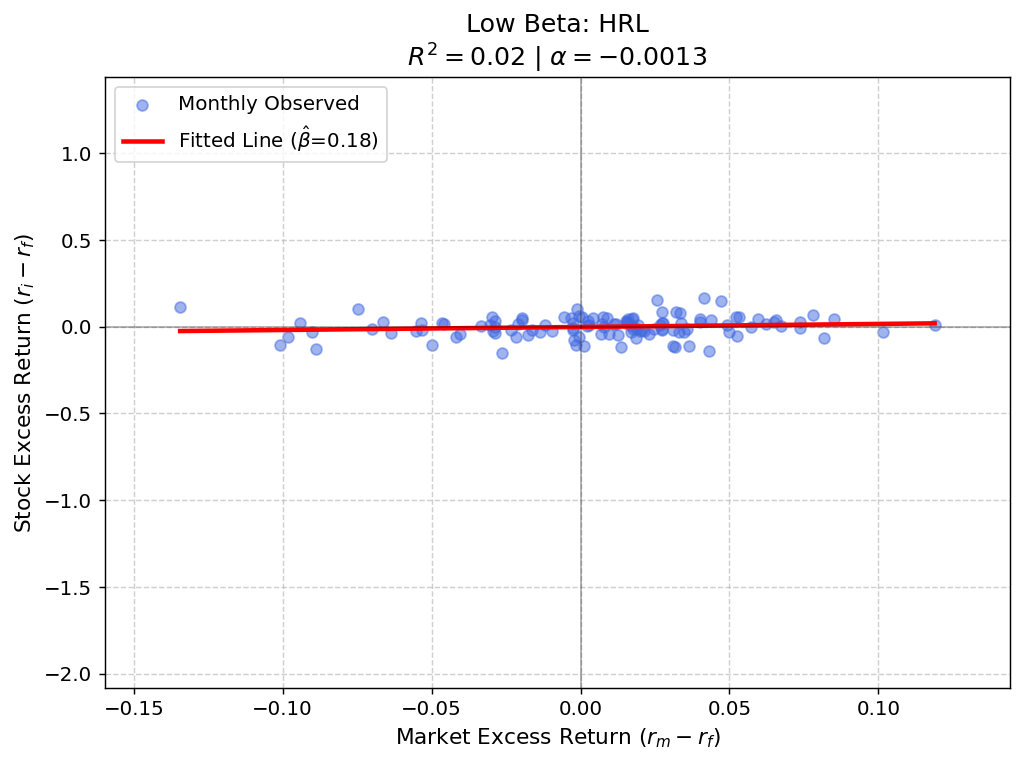

In [28]:
# 1. Prepare the reference dataframe
capm_stats = capm_stats_df.set_index('Ticker')
sorted_beta = capm_stats.sort_values('Beta')

valid_tickers = sorted_beta.index
low_ticker = valid_tickers[0]
high_ticker = valid_tickers[-1]
mid_ticker = valid_tickers[len(valid_tickers)//2]

tickers_to_plot = [
    ('High Beta', high_ticker),
    ('Mid-Range Beta', mid_ticker),
    ('Low Beta', low_ticker)
]

# 2. Determine Global Axis Limits for Standardization
# We look at all three stocks and the market to find the absolute min/max
all_y_values = pd.concat([monthly_excess_stocks[t] for _, t in tickers_to_plot])
y_min, y_max = all_y_values.min(), all_y_values.max()
x_min, x_max = monthly_excess_market.min(), monthly_excess_market.max()

# Add a 10% buffer so points aren't touching the edge of the frame
y_buffer = (y_max - y_min) * 0.1
x_buffer = (x_max - x_min) * 0.1

# 3. Create Three Separate Figures
for label, ticker in tickers_to_plot:
    plt.figure(figsize=(8, 6))

    x = monthly_excess_market
    y = monthly_excess_stocks[ticker]

    alpha = capm_stats.loc[ticker, 'Alpha']
    beta = capm_stats.loc[ticker, 'Beta']
    r2 = capm_stats.loc[ticker, 'R_Squared']

    # Scatter plot of actual data
    plt.scatter(x, y, alpha=0.5, color='royalblue', label='Monthly Observed')

    # Regression line
    x_range = np.linspace(x_min, x_max, 100)
    y_line = alpha + beta * x_range
    plt.plot(x_range, y_line, color='red', lw=2.5, label=f'Fitted Line ($\\hat{{\\beta}}$={beta:.2f})')

    # Apply standardized limits
    plt.ylim(y_min - y_buffer, y_max + y_buffer)
    plt.xlim(x_min - x_buffer, x_max + x_buffer)

    # Formatting
    plt.title(f"{label}: {ticker}\n$R^2 = {r2:.2f}$ | $\\alpha = {alpha:.4f}$", fontsize=14)
    plt.xlabel("Market Excess Return ($r_m - r_f$)", fontsize=12)
    plt.ylabel("Stock Excess Return ($r_i - r_f$)", fontsize=12)
    plt.axhline(0, color='black', lw=1, alpha=0.3)
    plt.axvline(0, color='black', lw=1, alpha=0.3)
    plt.legend(loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

### Task C) Plotting the Security Market Line (SML)

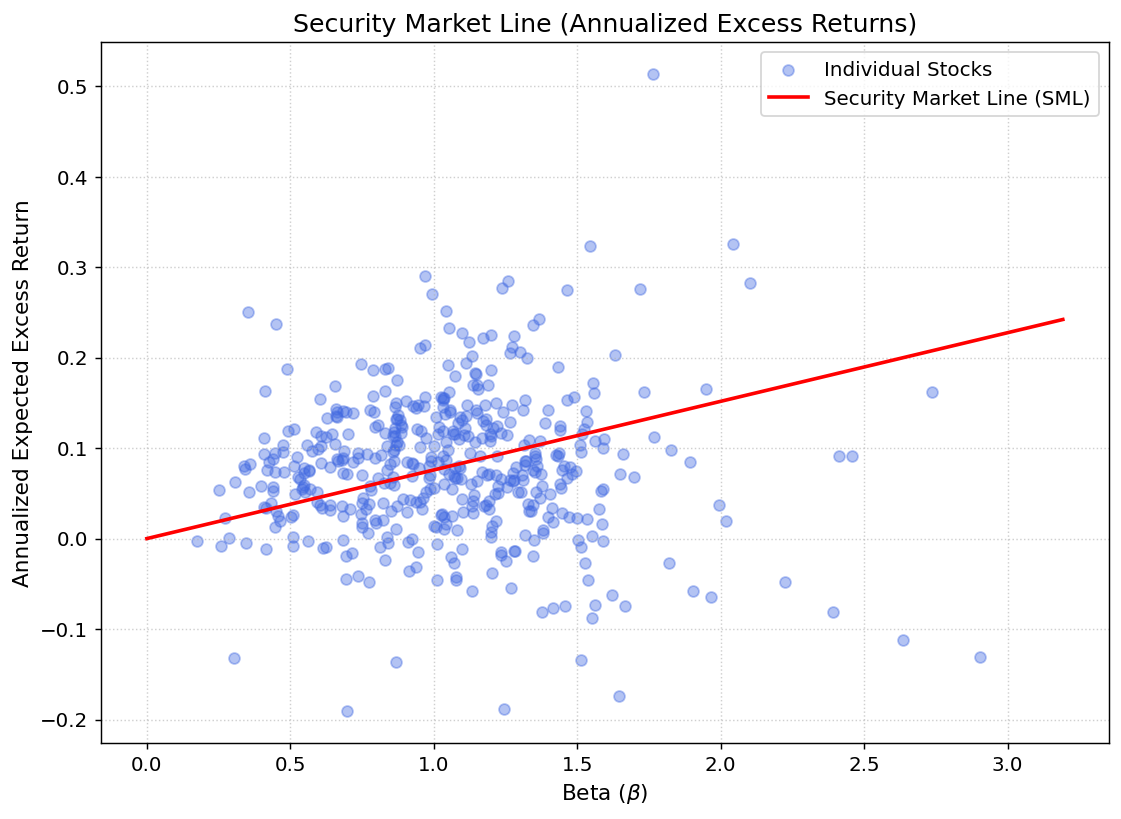

In [29]:
# 1. Calculate the components for the SML
# We use annualized excess returns for the y-axis
# and the Betas we calculated from the monthly regressions for the x-axis
sml_data = pd.DataFrame({
    'Beta': capm_stats['Beta'],
    'Annualized_Ex_Return': annualized_excess_returns # From Part B
}).dropna()

# 2. Define the SML Line
# The SML starts at 0 on the y-axis (since we are using EXCESS returns)
# and goes through the Market Portfolio (Beta = 1, Return = Market Excess Return)
market_excess_annual = monthly_excess_market.mean() * 12
beta_range = np.linspace(0, sml_data['Beta'].max() * 1.1, 100)
sml_line = market_excess_annual * beta_range

# 3. Create the Plot
plt.figure(figsize=(10, 7))

# Plot all stocks
plt.scatter(sml_data['Beta'], sml_data['Annualized_Ex_Return'],
            alpha=0.4, color='royalblue', label='Individual Stocks')

# Plot the SML Line
plt.plot(beta_range, sml_line, color='red', lw=2, label='Security Market Line (SML)')

# --- THE FIX IS HERE ---
plt.title('Security Market Line (Annualized Excess Returns)', fontsize=14)
plt.xlabel(r'Beta ($\beta$)', fontsize=12)  # Use r'' and close the $ correctly
plt.ylabel('Annualized Expected Excess Return', fontsize=12)
# -----------------------

plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [30]:
sml_data

,Beta,Annualized_Ex_Return
A,1.160041,0.091107
AAPL,1.200960,0.186199
ABBV,0.683395,0.140791
ABT,0.836663,0.101829
ACGL,0.664039,0.134043
...,...,...
XYL,1.067953,0.115192
YUM,0.858467,0.095448
ZBH,1.070593,-0.027399
ZBRA,1.658485,0.093939


### Task D)

In [31]:
above_capm = capm_stats_df.sort_values(by='Alpha', ascending=False).head(2)
above_capm

,Ticker,Alpha,Beta,R_Squared,StdErr_Beta
323,NVDA,0.031166,1.765013,0.350209,0.220393
264,LLY,0.018386,0.352090,0.046921,0.145467


In [32]:
below_capm = capm_stats_df.sort_values(by='Alpha', ascending=True).head(2)
below_capm

,Ticker,Alpha,Beta,R_Squared,StdErr_Beta
35,APA,-0.029114,2.902182,0.292448,0.413815
308,NCLH,-0.025916,2.635043,0.416403,0.285966


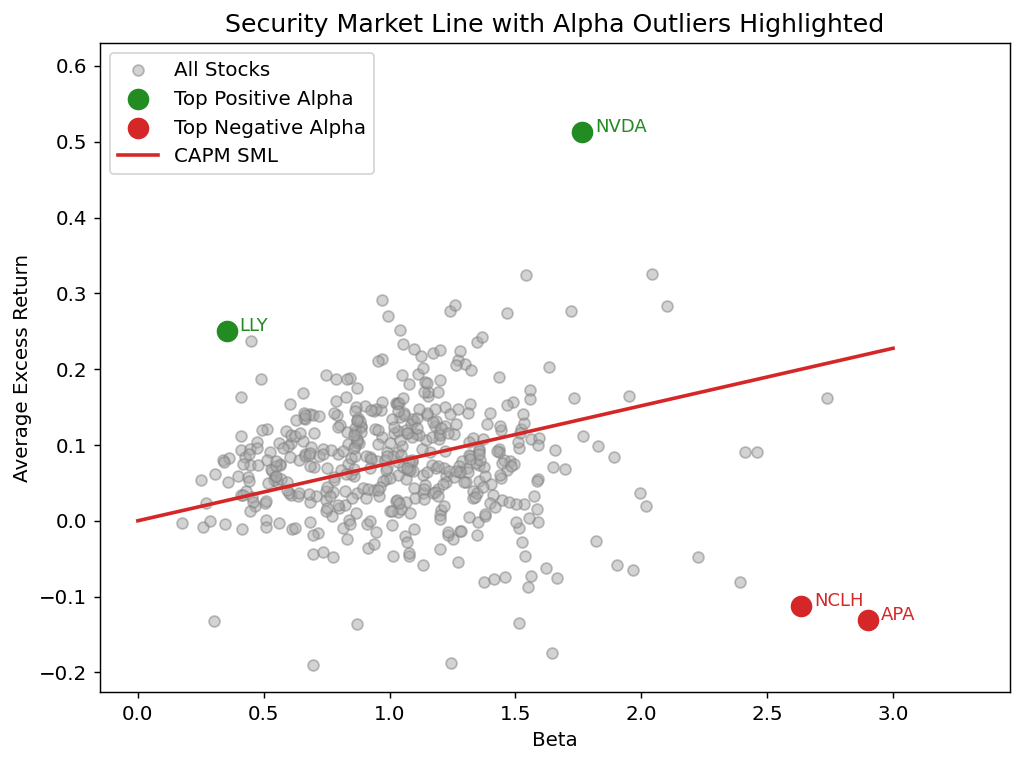

In [33]:
# Assuming sml_data and market_excess_annual are already defined from your previous steps
# market_excess_annual = monthly_excess_market.mean() * 12

# 1. Setup the figure
plt.figure(figsize=(8, 6))

# 2. Plot all stocks in grey (to match your screenshot)
plt.scatter(sml_data['Beta'], sml_data['Annualized_Ex_Return'],
            alpha=0.5, color='darkgrey', label='All Stocks', edgecolors='grey')

# 3. Identify and Plot Outliers (Based on your image)
# We find the specific tickers to highlight them in green/red
top_pos = above_capm['Ticker'].tolist()
top_neg = below_capm['Ticker'].tolist()
# Plot Green Outliers
for ticker in top_pos:
    if ticker in sml_data.index:
        x = sml_data.loc[ticker, 'Beta']
        y = sml_data.loc[ticker, 'Annualized_Ex_Return']
        plt.scatter(x, y, color='forestgreen', s=120, label='Top Positive Alpha' if ticker == 'NVDA' else "")
        plt.text(x + 0.05, y, ticker, color='forestgreen', fontsize=10, fontweight='medium')

# Plot Red Outliers
for ticker in top_neg:
    if ticker in sml_data.index:
        x = sml_data.loc[ticker, 'Beta']
        y = sml_data.loc[ticker, 'Annualized_Ex_Return']
        plt.scatter(x, y, color='tab:red', s=120, label='Top Negative Alpha' if ticker == 'NCLH' else "")
        plt.text(x + 0.05, y, ticker, color='tab:red', fontsize=10, fontweight='medium')

# 4. Define and Plot the SML Line (Market Excess Return slope)
beta_range = np.linspace(0, 3.0, 100) # Adjusted range to match image x-axis
sml_line = market_excess_annual * beta_range
plt.plot(beta_range, sml_line, color='tab:red', lw=2, label='CAPM SML')

# 5. Formatting to match the screenshot
plt.title('Security Market Line with Alpha Outliers Highlighted', fontsize=14)
plt.xlabel('Beta', fontsize=11)
plt.ylabel('Average Excess Return', fontsize=11)

# Move legend to top left
plt.legend(loc='upper left', frameon=True)

# Set axes limits to match the screenshot roughly
# Increase the top margin by 15% and the right margin by 10%
current_ylim = plt.ylim()
current_xlim = plt.xlim()

plt.ylim(current_ylim[0], current_ylim[1] * 1.15)
plt.xlim(current_xlim[0], current_xlim[1] * 1.10)

plt.tight_layout()

plt.show()

## Part 3: The Efficient Frontier

In [34]:
import matplotlib.ticker as mtick
import cvxpy as cp

%matplotlib inline
plt.rcParams.update({"figure.dpi": 130, "font.size": 11})

In [35]:
# Bridge from Part 1 outputs into Q3 variable names
tickers   = list(price_cols)
mu_hat    = annualized_excess_returns.values   # shape (N,)  annualised excess returns
Sigma_hat = annualized_cov.values              # shape (N, N) annualised covariance matrix
rf_annual = 252 * daily_treasury_rates['RF_Rate'].mean()
N         = len(mu_hat)

print(f"Universe  : {N} stocks")
print(f"mu_hat    : shape={mu_hat.shape}  min={mu_hat.min():.4f}  max={mu_hat.max():.4f}")
print(f"Sigma_hat : shape={Sigma_hat.shape}")
print(f"rf_annual : {rf_annual:.4f}  ({rf_annual:.2%})")

Universe  : 472 stocks
mu_hat    : shape=(472,)  min=-0.1909  max=0.5131
Sigma_hat : shape=(472, 472)
rf_annual : 0.0249  (2.49%)


---
## Helper Functions

- `compute_abcd` — scalars A, B, C, D from the closed-form derivation
- `algebraic_frontier_weights` — closed-form w*(mu_target) via Cramer's rule
- `portfolio_stats` — (return, volatility) for any weight vector
- `qp_min_var` — CVXPY quadratic program (unconstrained or long-only)

In [36]:
def compute_abcd(mu, Sigma_inv):
    """
    A = 1' Sigma^{-1} mu
    B = mu' Sigma^{-1} mu
    C = 1'  Sigma^{-1} 1
    D = BC - A^2  (determinant of the 2x2 Lagrange-multiplier system)
    """
    ones = np.ones(len(mu))
    A = ones @ Sigma_inv @ mu
    B = mu   @ Sigma_inv @ mu
    C = ones @ Sigma_inv @ ones
    D = B * C - A**2
    return A, B, C, D


def algebraic_frontier_weights(mu_target, mu, Sigma_inv, A, B, C, D):
    """
    Closed-form minimum-variance weights for a given target return.
    Solved via Cramer's rule on the 2x2 Lagrangian system:
      lambda_1 = (C*mu_target - A) / D
      lambda_2 = (B - A*mu_target) / D
      w* = Sigma^{-1} (lambda_1*mu + lambda_2*1)
    """
    ones = np.ones(len(mu))
    lam1 = (C * mu_target - A) / D
    lam2 = (B - A * mu_target) / D
    return Sigma_inv @ (lam1 * mu + lam2 * ones)


def portfolio_stats(w, mu, Sigma):
    """Return (expected_excess_return, volatility) for weight vector w."""
    ret = float(w @ mu)
    vol = float(np.sqrt(w @ Sigma @ w))
    return ret, vol


def qp_min_var(mu, Sigma, mu_target, long_only=False):
    """
    Solve  min (1/2) w' Sigma w
    s.t.   w' mu = mu_target,  w' 1 = 1,  [w >= 0  if long_only]
    Returns weight vector or None if infeasible.
    """
    n = len(mu)
    w           = cp.Variable(n)
    objective   = cp.Minimize(0.5 * cp.quad_form(w, Sigma))
    constraints = [mu @ w == mu_target, cp.sum(w) == 1]
    if long_only:
        constraints.append(w >= 0)
    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.CLARABEL)
    return w.value


print("Helper functions defined.")

Helper functions defined.


---
## Compute Scalars A, B, C, D and Key Portfolios

**GMV portfolio:**
$$\vec{w}_{\text{GMV}} = \frac{\Sigma^{-1}\vec{1}}{C}, \qquad \mu_{\text{GMV}} = \frac{A}{C}$$

**Tangency portfolio** (maximum Sharpe; mu is already in excess return terms so rf = 0):
$$\vec{w}_{\text{tan}} \propto \Sigma^{-1}\boldsymbol{\mu}$$

In [37]:
Sigma_inv  = np.linalg.inv(Sigma_hat)
A, B, C, D = compute_abcd(mu_hat, Sigma_inv)

print(f"Scalars:  A={A:.4f}  B={B:.4f}  C={C:.4f}  D={D:.6f}")
print(f"D > 0 (required for unique solution): {D > 0}\n")

# ── GMV ───────────────────────────────────────────────────────────────────────
mu_gmv           = A / C
w_gmv            = (Sigma_inv @ np.ones(N)) / C
ret_gmv, vol_gmv = portfolio_stats(w_gmv, mu_hat, Sigma_hat)

print("GMV portfolio:")
print(f"  Expected excess return : {ret_gmv:.4f}  ({ret_gmv:.2%})")
print(f"  Volatility             : {vol_gmv:.4f}  ({vol_gmv:.2%})")
print(f"  Sharpe ratio           : {ret_gmv/vol_gmv:.4f}")
print(f"  Weights sum to 1       : {w_gmv.sum():.6f}")
print(f"  Negative weights       : {(w_gmv < 0).sum()} of {N}")
print(f"  Max weight             : {w_gmv.max():.4f}  ({tickers[np.argmax(w_gmv)]})")
print(f"  Min weight             : {w_gmv.min():.4f}  ({tickers[np.argmin(w_gmv)]})")
print(f"  # |w| > 1%             : {(np.abs(w_gmv) > 0.01).sum()}")
print(f"  Gross leverage         : {np.abs(w_gmv).sum():.4f}x")

# ── Tangency ──────────────────────────────────────────────────────────────────
ones         = np.ones(N)
w_tan_raw    = Sigma_inv @ mu_hat
w_tan        = w_tan_raw / (ones @ w_tan_raw)
ret_tan, vol_tan = portfolio_stats(w_tan, mu_hat, Sigma_hat)
sr_tan       = ret_tan / vol_tan

print("\nTangency portfolio:")
print(f"  Expected excess return : {ret_tan:.4f}  ({ret_tan:.2%})")
print(f"  Volatility             : {vol_tan:.4f}  ({vol_tan:.2%})")
print(f"  Sharpe ratio           : {sr_tan:.4f}")
print(f"  Weights sum to 1       : {w_tan.sum():.6f}")
print(f"  Negative weights       : {(w_tan < 0).sum()} of {N}")
print(f"  Max weight             : {w_tan.max():.4f}  ({tickers[np.argmax(w_tan)]})")
print(f"  Min weight             : {w_tan.min():.4f}  ({tickers[np.argmin(w_tan)]})")
print(f"  # |w| > 1%             : {(np.abs(w_tan) > 0.01).sum()}")
print(f"  Gross leverage         : {np.abs(w_tan).sum():.4f}x")

Scalars:  A=10.8292  B=22.5050  C=150.7864  D=3276.170494
D > 0 (required for unique solution): True

GMV portfolio:
  Expected excess return : 0.0718  (7.18%)
  Volatility             : 0.0814  (8.14%)
  Sharpe ratio           : 0.8819
  Weights sum to 1       : 1.000000
  Negative weights       : 219 of 472
  Max weight             : 0.0943  (ED)
  Min weight             : -0.0894  (AMP)
  # |w| > 1%             : 291
  Gross leverage         : 8.3570x

Tangency portfolio:
  Expected excess return : 2.0782  (207.82%)
  Volatility             : 0.4381  (43.81%)
  Sharpe ratio           : 4.7439
  Weights sum to 1       : 1.000000
  Negative weights       : 229 of 472
  Max weight             : 0.4817  (GOOG)
  Min weight             : -0.5080  (D)
  # |w| > 1%             : 445
  Gross leverage         : 48.7062x


---
## Trace the Algebraic Efficient Frontier (3.1b)

Evaluate w*(mu_target) at 400 evenly-spaced target returns across the full range.

In [38]:
mu_grid = np.linspace(mu_gmv * 0.5, max(mu_hat.max(), ret_tan) * 1.1, 400)

frontier_ret = []
frontier_vol = []

for mu_t in mu_grid:
    w_t = algebraic_frontier_weights(mu_t, mu_hat, Sigma_inv, A, B, C, D)
    r, v = portfolio_stats(w_t, mu_hat, Sigma_hat)
    frontier_ret.append(r)
    frontier_vol.append(v)

frontier_ret = np.array(frontier_ret)
frontier_vol = np.array(frontier_vol)
eff_mask     = frontier_ret >= ret_gmv

print(f"Frontier traced over {len(mu_grid)} target returns.")
print(f"Efficient segment: {eff_mask.sum()} points")

Frontier traced over 400 target returns.
Efficient segment: 393 points


---
## Plot: Algebraic Frontier + CML (3.1b)

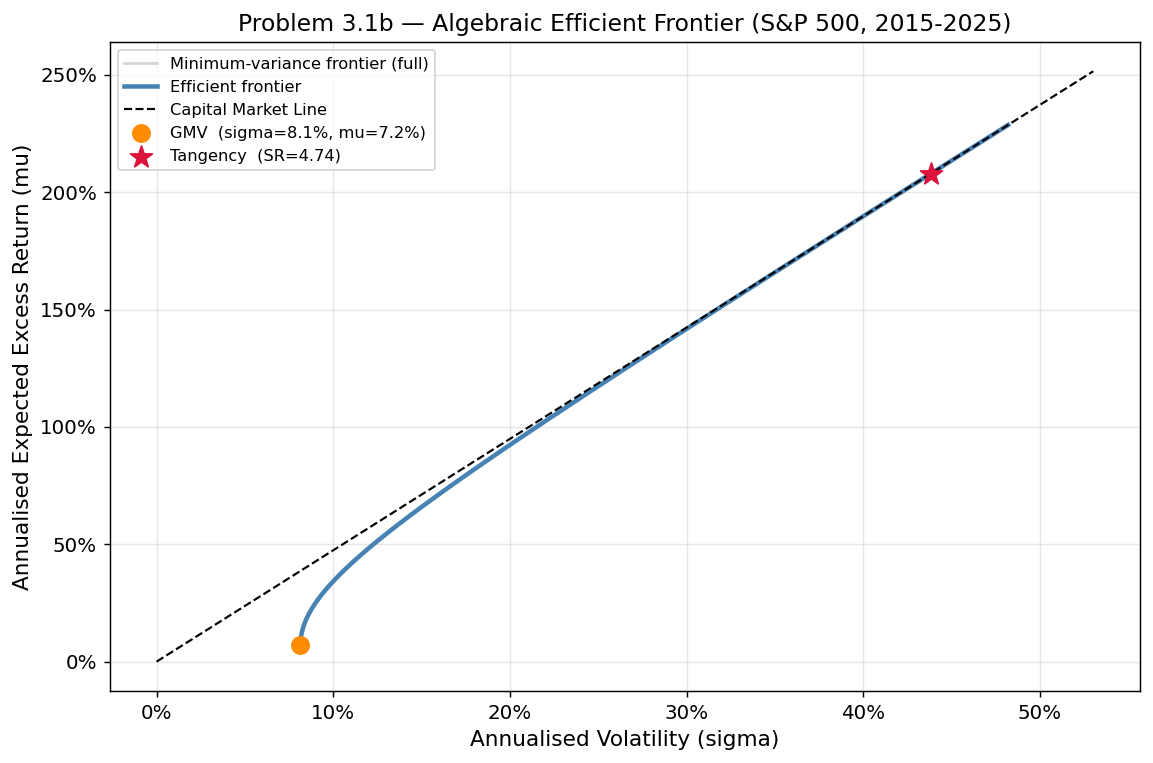

In [39]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(frontier_vol, frontier_ret,
        color="lightgray", lw=1.5, label="Minimum-variance frontier (full)")
ax.plot(frontier_vol[eff_mask], frontier_ret[eff_mask],
        color="steelblue", lw=2.5, label="Efficient frontier")

# Capital Market Line (origin = 0 since mu is already excess)
cml_vol = np.linspace(0, frontier_vol.max() * 1.1, 100)
ax.plot(cml_vol, sr_tan * cml_vol, "k--", lw=1.2, label="Capital Market Line")

ax.scatter(vol_gmv, ret_gmv, zorder=5, s=90, color="darkorange",
           label=f"GMV  (sigma={vol_gmv:.1%}, mu={ret_gmv:.1%})")
ax.scatter(vol_tan, ret_tan, zorder=5, s=160, color="crimson", marker="*",
           label=f"Tangency  (SR={sr_tan:.2f})")

ax.set_xlabel("Annualised Volatility (sigma)", fontsize=12)
ax.set_ylabel("Annualised Expected Excess Return (mu)", fontsize=12)
ax.set_title("Problem 3.1b — Algebraic Efficient Frontier (S&P 500, 2015-2025)", fontsize=13)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("fig_3_1_algebraic_frontier.png", dpi=150)
plt.show()

---
## Weight Detail Tables (3.1c)

Top and bottom holdings for both portfolios.

In [40]:
gmv_df = (pd.DataFrame({"Ticker": tickers, "Weight": w_gmv})
           .sort_values("Weight", ascending=False)
           .reset_index(drop=True))

tan_df = (pd.DataFrame({"Ticker": tickers, "Weight": w_tan})
           .sort_values("Weight", ascending=False)
           .reset_index(drop=True))

summary = pd.DataFrame({
    "Metric": [
        "Expected excess return",
        "Volatility",
        "Sharpe ratio",
        "Weights sum",
        "Negative weights",
        "Max weight (ticker)",
        "Min weight (ticker)",
        "# |w| > 1%",
        "Gross leverage",
    ],
    "GMV": [
        f"{ret_gmv:.4f}  ({ret_gmv:.2%})",
        f"{vol_gmv:.4f}  ({vol_gmv:.2%})",
        f"{ret_gmv/vol_gmv:.4f}",
        f"{w_gmv.sum():.6f}",
        f"{(w_gmv < 0).sum()} of {N}",
        f"{w_gmv.max():.4f}  ({tickers[np.argmax(w_gmv)]})",
        f"{w_gmv.min():.4f}  ({tickers[np.argmin(w_gmv)]})",
        f"{(np.abs(w_gmv) > 0.01).sum()}",
        f"{np.abs(w_gmv).sum():.4f}x",
    ],
    "Tangency": [
        f"{ret_tan:.4f}  ({ret_tan:.2%})",
        f"{vol_tan:.4f}  ({vol_tan:.2%})",
        f"{sr_tan:.4f}",
        f"{w_tan.sum():.6f}",
        f"{(w_tan < 0).sum()} of {N}",
        f"{w_tan.max():.4f}  ({tickers[np.argmax(w_tan)]})",
        f"{w_tan.min():.4f}  ({tickers[np.argmin(w_tan)]})",
        f"{(np.abs(w_tan) > 0.01).sum()}",
        f"{np.abs(w_tan).sum():.4f}x",
    ],
})

print("=" * 70)
print("3.1c — Portfolio Summary")
print("=" * 70)
display(summary)

print("\nTop 10 Tangency weights:")
display(tan_df.head(10))

print("\nBottom 10 Tangency weights (largest short positions):")
display(tan_df.tail(10))

3.1c — Portfolio Summary


,Metric,GMV,Tangency
0,Expected excess return,0.0718 (7.18%),2.0782 (207.82%)
1,Volatility,0.0814 (8.14%),0.4381 (43.81%)
2,Sharpe ratio,0.8819,4.7439
3,Weights sum,1.000000,1.000000
4,Negative weights,219 of 472,229 of 472
5,Max weight (ticker),0.0943 (ED),0.4817 (GOOG)
6,Min weight (ticker),-0.0894 (AMP),-0.5080 (D)
7,# |w| > 1%,291,445
8,Gross leverage,8.3570x,48.7062x



Top 10 Tangency weights:


,Ticker,Weight
0,GOOG,0.481674
1,ATO,0.413240
2,DTE,0.400477
3,LRCX,0.371421
4,REG,0.365189
5,WELL,0.350957
6,JPM,0.347420
7,ADI,0.340123
8,MS,0.333939
9,CAT,0.324058



Bottom 10 Tangency weights (largest short positions):


,Ticker,Weight
462,ECL,-0.256721
463,C,-0.272978
464,ZBH,-0.290358
465,VMC,-0.301572
466,ES,-0.336049
467,L,-0.375203
468,FRT,-0.402151
469,GOOGL,-0.415577
470,LEN,-0.433276
471,D,-0.508034


---
## QP Solver: Unconstrained Frontier (3.2a)

Solve with CVXPY and verify the frontier matches the algebraic solution.
The max absolute difference in volatility should be on the order of 1e-7 or smaller.

Max |QP vol - Algebraic vol| across all grid points: 2.04e-15
Match confirmed


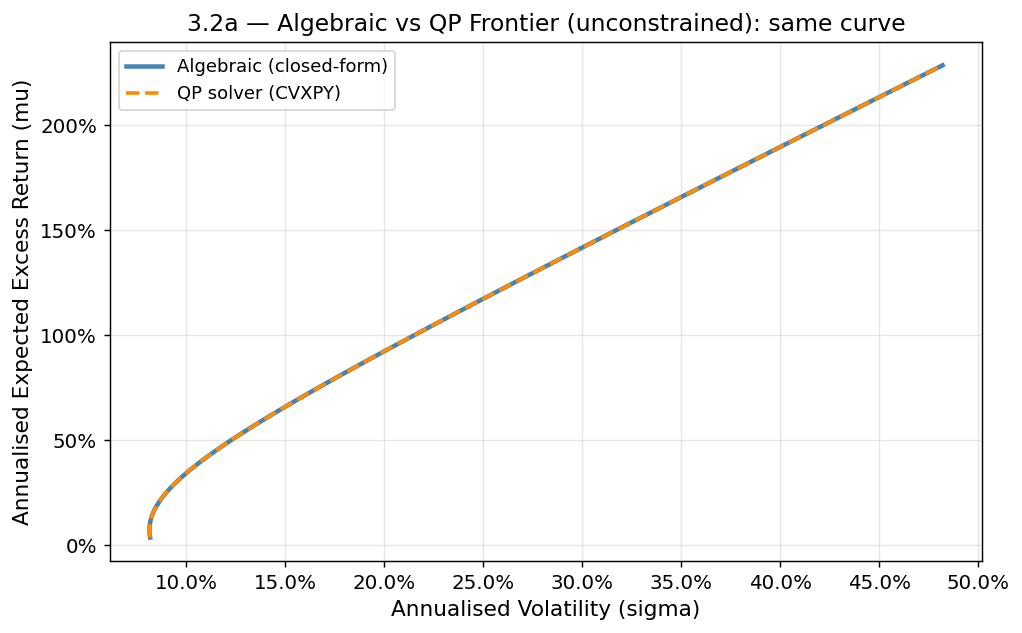

In [41]:
qp_ret_unc = []
qp_vol_unc = []

for mu_t in mu_grid:
    w_qp = qp_min_var(mu_hat, Sigma_hat, mu_t, long_only=False)
    if w_qp is None:
        qp_ret_unc.append(np.nan)
        qp_vol_unc.append(np.nan)
        continue
    r, v = portfolio_stats(w_qp, mu_hat, Sigma_hat)
    qp_ret_unc.append(r)
    qp_vol_unc.append(v)

qp_ret_unc = np.array(qp_ret_unc)
qp_vol_unc = np.array(qp_vol_unc)

max_diff = np.nanmax(np.abs(qp_vol_unc - frontier_vol))
print(f"Max |QP vol - Algebraic vol| across all grid points: {max_diff:.2e}")
print("Match confirmed" if max_diff < 1e-5 else "Discrepancy -- check solver tolerance")

# Plot: algebraic vs QP frontier to show they are the same
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(frontier_vol, frontier_ret, color="steelblue", lw=2.5, label="Algebraic (closed-form)")
ax.plot(qp_vol_unc, qp_ret_unc, color="darkorange", lw=2, linestyle="--", label="QP solver (CVXPY)")
ax.set_xlabel("Annualised Volatility (sigma)", fontsize=12)
ax.set_ylabel("Annualised Expected Excess Return (mu)", fontsize=12)
ax.set_title("3.2a — Algebraic vs QP Frontier (unconstrained): same curve", fontsize=13)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## QP Solver: Long-only Frontier (3.2b)

Add the constraint w_i >= 0 for all i and re-solve across the same return grid.

**Note:** This cell is slow on a 472-stock universe. To speed it up, either reduce
the grid size in Cell 5 (e.g. 50 points instead of 400), loosen solver tolerances
to eps_abs=1e-5, or switch to solver=cp.CLARABEL.

In [43]:
qp_ret_lo = []
qp_vol_lo = []

for mu_t in mu_grid:
    w_qp = qp_min_var(mu_hat, Sigma_hat, mu_t, long_only=True)
    if w_qp is None:
        qp_ret_lo.append(np.nan)
        qp_vol_lo.append(np.nan)
        continue
    r, v = portfolio_stats(w_qp, mu_hat, Sigma_hat)
    qp_ret_lo.append(r)
    qp_vol_lo.append(v)

qp_ret_lo = np.array(qp_ret_lo)
qp_vol_lo = np.array(qp_vol_lo)

# Efficient long-only segment
valid_lo    = ~np.isnan(qp_vol_lo) & (qp_ret_lo >= ret_gmv)

# Long-only tangency: grid point with highest Sharpe on the efficient segment
sr_lo_grid  = np.where(valid_lo, qp_ret_lo / qp_vol_lo, -np.inf)
best_lo     = np.argmax(sr_lo_grid)
ret_tan_lo  = qp_ret_lo[best_lo]
vol_tan_lo  = qp_vol_lo[best_lo]
w_tan_lo    = qp_min_var(mu_hat, Sigma_hat, mu_grid[best_lo], long_only=True)

print("Long-only tangency:")
print(f"  Expected excess return : {ret_tan_lo:.4f}  ({ret_tan_lo:.2%})")
print(f"  Volatility             : {vol_tan_lo:.4f}  ({vol_tan_lo:.2%})")
print(f"  Sharpe ratio           : {ret_tan_lo/vol_tan_lo:.4f}")
print(f"  Non-zero weights       : {(w_tan_lo > 1e-4).sum()} of {N}")
print(f"  Infeasible grid points : {np.isnan(qp_vol_lo).sum()} of {len(mu_grid)}")

Long-only tangency:
  Expected excess return : 0.2840  (28.40%)
  Volatility             : 0.1933  (19.33%)
  Sharpe ratio           : 1.4696
  Non-zero weights       : 9 of 472
  Infeasible grid points : 315 of 400


---
## Plot: Unconstrained vs Long-only Frontier (3.2b)

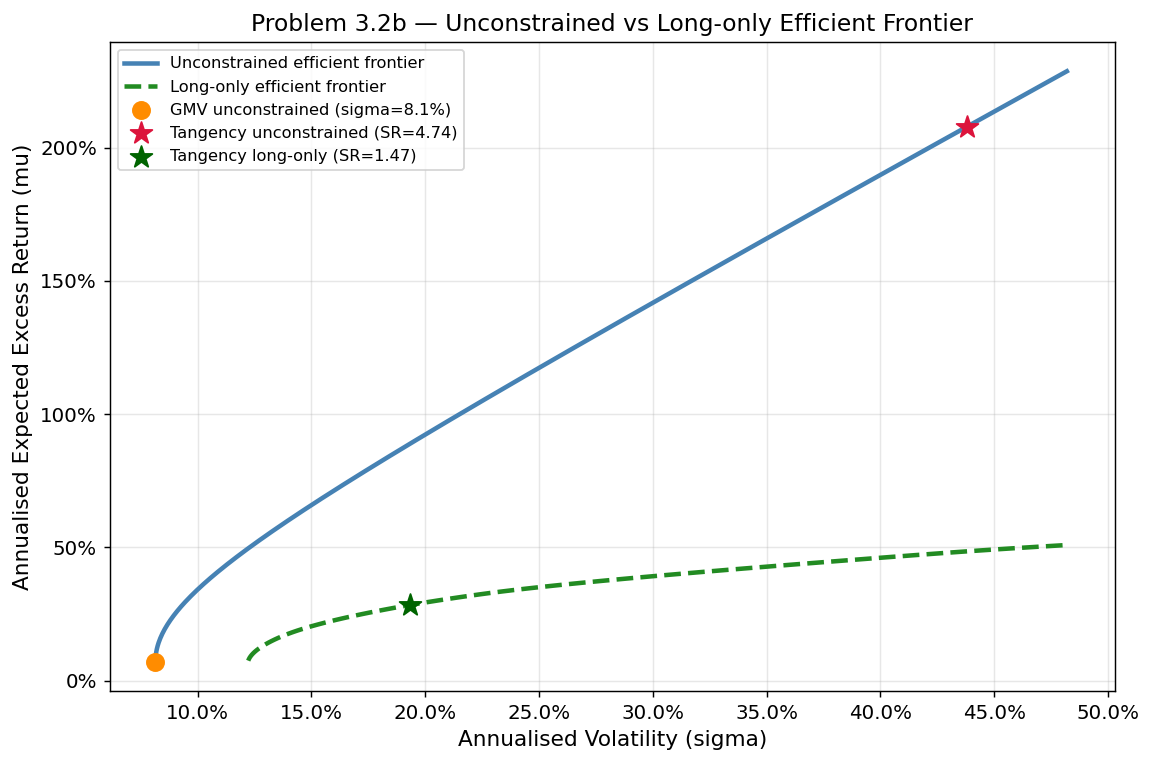

In [44]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(frontier_vol[eff_mask], frontier_ret[eff_mask],
        color="steelblue", lw=2.5, label="Unconstrained efficient frontier")
ax.plot(qp_vol_lo[valid_lo], qp_ret_lo[valid_lo],
        color="forestgreen", lw=2.5, linestyle="--", label="Long-only efficient frontier")

ax.scatter(vol_gmv, ret_gmv, zorder=5, s=90, color="darkorange",
           label=f"GMV unconstrained (sigma={vol_gmv:.1%})")
ax.scatter(vol_tan, ret_tan, zorder=5, s=160, color="crimson", marker="*",
           label=f"Tangency unconstrained (SR={sr_tan:.2f})")
ax.scatter(vol_tan_lo, ret_tan_lo, zorder=5, s=160, color="darkgreen", marker="*",
           label=f"Tangency long-only (SR={ret_tan_lo/vol_tan_lo:.2f})")

ax.set_xlabel("Annualised Volatility (sigma)", fontsize=12)
ax.set_ylabel("Annualised Expected Excess Return (mu)", fontsize=12)
ax.set_title("Problem 3.2b — Unconstrained vs Long-only Efficient Frontier", fontsize=13)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("fig_3_2_qp_frontiers.png", dpi=150)
plt.show()

---
## Comparison Table: Unconstrained vs Long-only (3.2c)

In [45]:
sr_tan_lo = ret_tan_lo / vol_tan_lo

comparison = pd.DataFrame({
    "Metric": [
        "Expected excess return",
        "Volatility",
        "Sharpe ratio",
        "Sharpe ratio cost of long-only",
        "Negative weights",
        "Non-zero weights",
        "Max weight (ticker)",
        "Min weight (ticker)",
        "Gross leverage",
    ],
    "Unconstrained": [
        f"{ret_tan:.4f}  ({ret_tan:.2%})",
        f"{vol_tan:.4f}  ({vol_tan:.2%})",
        f"{sr_tan:.4f}",
        "N/A",
        f"{(w_tan < 0).sum()} of {N}",
        f"{(np.abs(w_tan) > 1e-4).sum()} of {N}",
        f"{w_tan.max():.4f}  ({tickers[np.argmax(w_tan)]})",
        f"{w_tan.min():.4f}  ({tickers[np.argmin(w_tan)]})",
        f"{np.abs(w_tan).sum():.4f}x",
    ],
    "Long-only": [
        f"{ret_tan_lo:.4f}  ({ret_tan_lo:.2%})",
        f"{vol_tan_lo:.4f}  ({vol_tan_lo:.2%})",
        f"{sr_tan_lo:.4f}",
        f"{sr_tan - sr_tan_lo:.4f}  ({(sr_tan - sr_tan_lo)/sr_tan:.1%} of unconstrained SR)",
        "0  (by construction)",
        f"{(w_tan_lo > 1e-4).sum()} of {N}",
        f"{w_tan_lo.max():.4f}  ({tickers[np.argmax(w_tan_lo)]})",
        f"{w_tan_lo.min():.4f}",
        f"{np.abs(w_tan_lo).sum():.4f}x",
    ],
})

display(comparison)

print("\n" + "-" * 65)
print("Interpretation:")
print("  The long-only frontier lies to the RIGHT of the unconstrained")
print("  frontier for every target return above the GMV: prohibiting")
print("  short selling forces more risk for the same return.")
print(f"  Sharpe ratio penalty: {sr_tan - sr_tan_lo:.4f} ({(sr_tan - sr_tan_lo)/sr_tan:.1%} of unconstrained SR).")

,Metric,Unconstrained,Long-only
0,Expected excess return,2.0782 (207.82%),0.2840 (28.40%)
1,Volatility,0.4381 (43.81%),0.1933 (19.33%)
2,Sharpe ratio,4.7439,1.4696
3,Sharpe ratio cost of long-only,N/A,3.2744 (69.0% of unconstrained SR)
4,Negative weights,229 of 472,0 (by construction)
5,Non-zero weights,472 of 472,9 of 472
6,Max weight (ticker),0.4817 (GOOG),0.2919 (PGR)
7,Min weight (ticker),-0.5080 (D),0.0000
8,Gross leverage,48.7062x,1.0000x



-----------------------------------------------------------------
Interpretation:
  The long-only frontier lies to the RIGHT of the unconstrained
  frontier for every target return above the GMV: prohibiting
  short selling forces more risk for the same return.
  Sharpe ratio penalty: 3.2744 (69.0% of unconstrained SR).


## Part 4 : MAXSER

In [ ]:
import random
import textwrap
from scipy.special import betainc, beta
from scipy.stats import gaussian_kde
from sklearn.linear_model import lars_path
from sklearn.model_selection import KFold

In [ ]:
np.random.seed(42)
random.seed(42)
stock_excess_monthly = monthly_excess_stocks.dropna(axis=1)
stocks = stock_excess_monthly.columns.tolist()
subpool_stocks  = []
theta_s_values  = []

In [ ]:
for _ in range(1000):
    sub   = random.sample(stocks, 50)
    data  = stock_excess_monthly[sub]
    mu    = data.mean().values
    Sigma = data.cov().values
    theta_s = mu @ np.linalg.solve(Sigma, mu)
    theta_s_values.append(theta_s)
    subpool_stocks.append(sub)

In [ ]:
T = stock_excess_monthly.shape[0]   # number of monthly observations
N = 50

theta_s_arr = np.array(theta_s_values)
theta_kz    = ((T - N - 2) * theta_s_arr - N) / T
threshold   = np.percentile(theta_kz, 95)

index             = np.argmin(np.abs(theta_kz - threshold))
selected_stocks   = subpool_stocks[index]
selected_theta_kz = theta_kz[index]
selected_theta_s  = theta_s_values[index]

,Median theta_kz,95th Percentile theta_kz,Max theta_kz,Negative theta_kz Count,Total Subpools
0,-0.065274,0.100483,0.303163,774,1000


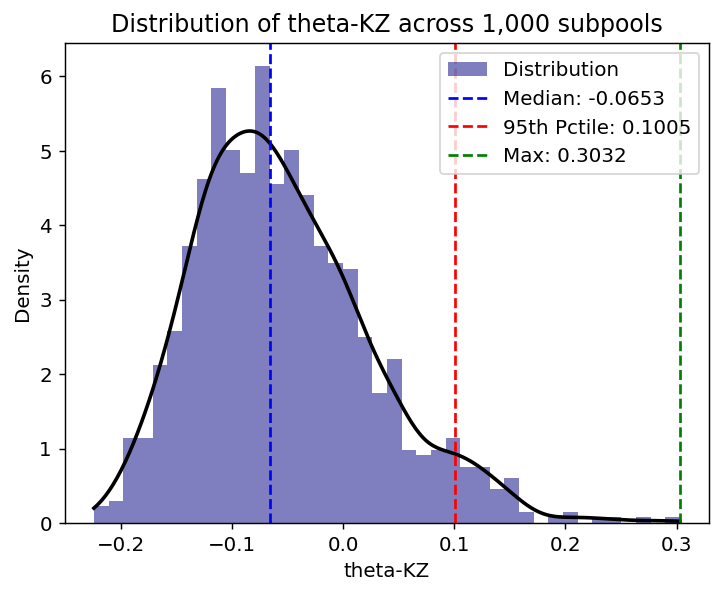

Selected theta_KZ: 0.1005
Selected theta_s:  0.9008

Selected Subpool (50 stocks):
ACGL, ADI, AME, AMZN, ANSS, AON, AVGO, AXP, AZO, BALL, BBY, BSX, CHRW, CNP,
CPAY, CRL, CVS, DECK, DHI, EFX, EIX, ERIE, ETN, EVRG, EXC, GL, HOLX, HSY, ICE,
IDXX, INCY, KDP, KEY, KIM, KMX, LDOS, LKQ, LUV, LYV, MA, MPWR, NVDA, ORCL, PM,
PODD, POOL, RL, TFC, TGT, WAB


In [ ]:
# Summary table
kz_report = pd.DataFrame({
    "Median theta_kz":          [np.median(theta_kz)],
    "95th Percentile theta_kz": [np.percentile(theta_kz, 95)],
    "Max theta_kz":             [np.max(theta_kz)],
    "Negative theta_kz Count":  [np.sum(theta_kz < 0)],
    "Total Subpools":           [len(theta_kz)],
})
display(kz_report)

# Distribution plot
fig, ax = plt.subplots()
ax.hist(theta_kz, bins=40, density=True, alpha=0.5, color='navy', label='Distribution')

kde = gaussian_kde(theta_kz)
x = np.linspace(theta_kz.min(), theta_kz.max(), 300)
ax.plot(x, kde(x), color='black', linewidth=2)

ax.axvline(np.median(theta_kz), color='blue', linestyle='--', label=f'Median: {np.median(theta_kz):.4f}')
ax.axvline(np.percentile(theta_kz, 95), color='red', linestyle='--', label=f'95th Pctile: {np.percentile(theta_kz, 95):.4f}')
ax.axvline(np.max(theta_kz), color='green', linestyle='--', label=f'Max: {np.max(theta_kz):.4f}')

ax.set_xlabel('theta-KZ')
ax.set_ylabel('Density')
ax.set_title('Distribution of theta-KZ across 1,000 subpools')
ax.legend()
plt.show()


print(f"Selected theta_KZ: {round(selected_theta_kz, 4)}")
print(f"Selected theta_s:  {round(selected_theta_s, 4)}")
print(f"\nSelected Subpool ({len(selected_stocks)} stocks):")
wrapped = textwrap.fill(", ".join(sorted(selected_stocks)), width=80)
print(wrapped)

### 4.2  Estimating the Squared Sharpe Ratio

### Task A): Reporting Theta_s, Kan-Zhou, and the ALZ correction

In [ ]:
x     = selected_theta_s / (1 + selected_theta_s)
a     = N / 2
b     = (T - N) / 2
Ix    = betainc(a, b, x)
B     = beta(a, b)

alz_term = (
    2 * selected_theta_s ** (N / 2) *
    (1 + selected_theta_s) ** (-(T - 2) / 2)
) / (T * Ix * B)

theta_hat = selected_theta_kz + alz_term

print(f"theta_s:      {selected_theta_s:.4f}")
print(f"Kan-Zhou:     {selected_theta_kz:.4f}")
print(f"ALZ correction: {alz_term:.4f}")
print(f"theta_hat:    {theta_hat:.4f}")

summary = pd.DataFrame({
    "Metric": [
        "Plug-in estimate (theta_s)",
        "Kan-Zhou term",
        "ALZ correction",
        "Final estimate (theta_hat)",
    ],
    "Value": [selected_theta_s, selected_theta_kz, alz_term, theta_hat],
    "% of Plug-in": [
        100.0,
        selected_theta_kz / selected_theta_s * 100,
        alz_term          / selected_theta_s * 100,
        theta_hat         / selected_theta_s * 100,
    ],
    "Direction": [
        "baseline",
        "downward correction (bias removal)",
        "upward correction (non-negative floor)",
        "net result",
    ],
})
summary["Value"]       = summary["Value"].round(4)
summary["% of Plug-in"] = summary["% of Plug-in"].round(1)
display(summary)

total_bias_pct = (selected_theta_s - theta_hat) / selected_theta_s * 100
print(f"Net bias correction: plug-in overstated by {total_bias_pct:.1f}%")
print(f"  Kan-Zhou shaves off: {abs(selected_theta_kz / selected_theta_s * 100):.1f}% of plug-in")
print(f"  ALZ adds back:       {alz_term / selected_theta_s * 100:.1f}% of plug-in")

theta_s:      0.9008
Kan-Zhou:     0.1005
ALZ correction: 0.0367
theta_hat:    0.1371


,Metric,Value,% of Plug-in,Direction
0,Plug-in estimate (theta_s),0.9008,100.0,baseline
1,Kan-Zhou term,0.1005,11.2,downward correction (bias removal)
2,ALZ correction,0.0367,4.1,upward correction (non-negative floor)
3,Final estimate (theta_hat),0.1371,15.2,net result


Net bias correction: plug-in overstated by 84.8%
  Kan-Zhou shaves off: 11.2% of plug-in
  ALZ adds back:       4.1% of plug-in


In [ ]:
risk_budget = 0.15
risk_budget_monthly = risk_budget / np.sqrt(12)
r_c = risk_budget_monthly * (1 + theta_hat) / np.sqrt(theta_hat)
print(f"Risk-Corrected Return (r_c): {r_c:.4f}")

Risk-Corrected Return (r_c): 0.1330


In [ ]:
X = stock_excess_monthly[selected_stocks].values
y = np.full(X.shape[0], r_c)
sigma_monthly = risk_budget_monthly

kf             = KFold(n_splits=10, shuffle=True, random_state=42)
zetas_selected = []

for train_idx, val_idx in kf.split(X):
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    alphas, actives, coefs_train = lars_path(X_train, y_train, method='lasso')

    w_ols_l1 = np.sum(np.abs(coefs_train[:, -1]))
    if w_ols_l1 == 0:
        continue
    zetas = np.sum(np.abs(coefs_train), axis=0) / w_ols_l1

    val_vols = np.array([
        np.std(X_val @ coefs_train[:, j])
        for j in range(coefs_train.shape[1])
    ])

    best_vol = np.argmin(np.abs(val_vols - sigma_monthly))
    zetas_selected.append(zetas[best_vol])

zeta_avg = np.mean(zetas_selected)
print("Average zeta from CV:", zeta_avg)

Average zeta from CV: 0.1780617307108794


In [ ]:
# Full-sample LARS path
alphas_full, actives_full, coefs_full = lars_path(X, y, method='lasso')

w_ols_l1_full = np.sum(np.abs(coefs_full[:, -1]))
zetas_full = np.sum(np.abs(coefs_full), axis=0) / w_ols_l1_full

best_step = np.argmin(np.abs(zetas_full - zeta_avg))
w_maxser = coefs_full[:, best_step]

w_maxser_series = pd.Series(w_maxser, index=selected_stocks)
nonzero = w_maxser_series[w_maxser_series != 0].sort_values(ascending=False)

print(f"Nonzero weights: {len(nonzero)}")

Nonzero weights: 18


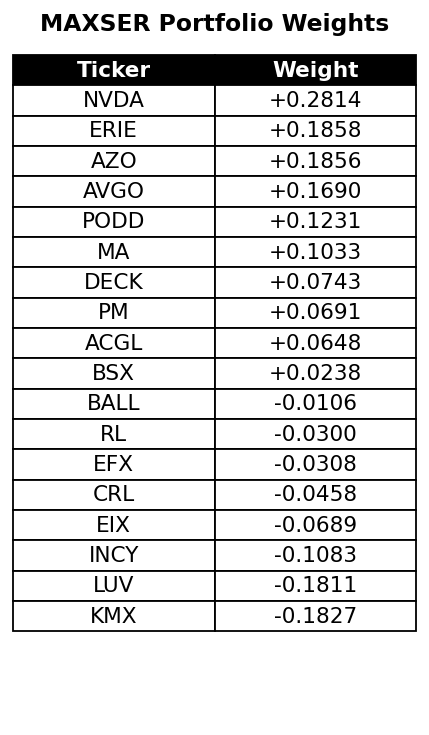

In [ ]:
weights_df = nonzero.reset_index()
weights_df.columns = ['Ticker', 'Weight']
weights_df['Weight'] = weights_df['Weight'].round(4)

formatted_weights = [f'+{w:.4f}' if w > 0 else f'{w:.4f}' for w in weights_df['Weight']]

fig, ax = plt.subplots(figsize=(4, len(weights_df) * 0.35 + 0.5))
ax.axis('off')

table = ax.table(
    cellText=list(zip(weights_df['Ticker'], formatted_weights)),
    colLabels=['Ticker', 'Weight'],
    loc='upper center',
    cellLoc='center'
)

ax.set_title('MAXSER Portfolio Weights', fontsize=13,
             fontweight='bold', pad=6)

table.auto_set_font_size(False)
table.set_fontsize(12)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor('black')
    cell.set_linewidth(1)
    if row == 0:
        cell.set_facecolor('black')
        cell.set_text_props(color='white', fontweight='bold')
    else:
        cell.set_facecolor('white')

table.scale(1, 1.4)
plt.savefig("weights_table.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
mu_sub = stock_excess_monthly[selected_stocks].mean().values
Sigma_sub = stock_excess_monthly[selected_stocks].cov().values
Sigma_sub_inv = np.linalg.inv(Sigma_sub)

w_plugin = (sigma_monthly / np.sqrt(selected_theta_s)) * (Sigma_sub_inv @ mu_sub)
print(f"Plug-in sum of weights: {w_plugin.sum():.4f}")
print(f"Plug-in portfolio vol:  {np.sqrt(w_plugin @ Sigma_sub @ w_plugin):.4f}")

Plug-in sum of weights: 0.6560
Plug-in portfolio vol:  0.0433


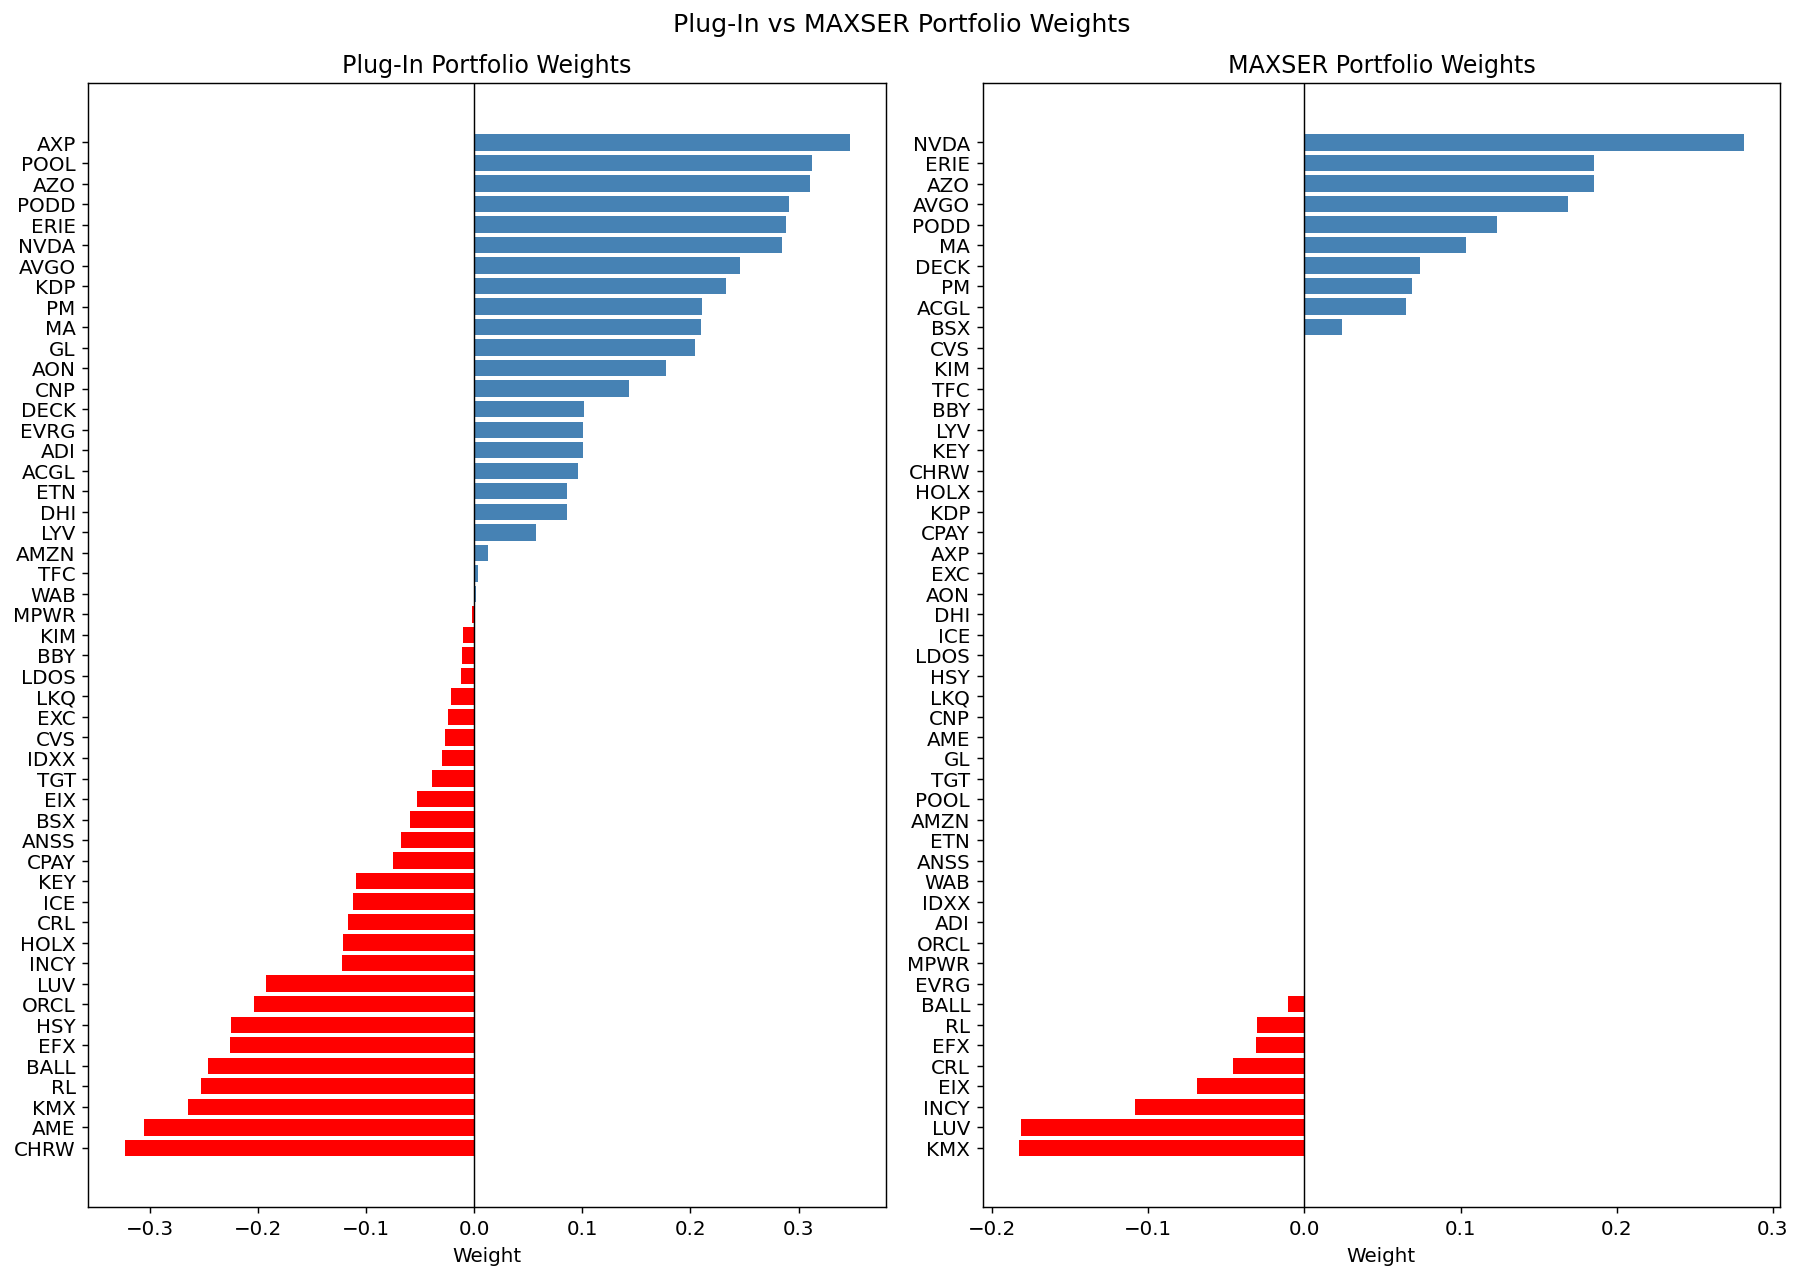

In [ ]:
# Bar charts
fig, axes = plt.subplots(1, 2, figsize=(14, 10))

w_plugin_series = pd.Series(w_plugin, index=selected_stocks).sort_values()
colors_plugin   = ['red' if x < 0 else 'steelblue' for x in w_plugin_series]
axes[0].barh(w_plugin_series.index, w_plugin_series.values, color=colors_plugin)
axes[0].axvline(x=0, color='black', linewidth=0.8)
axes[0].set_title("Plug-In Portfolio Weights")
axes[0].set_xlabel("Weight")

w_maxser_plot = pd.Series(w_maxser, index=selected_stocks).sort_values()
colors_maxser   = ['red' if x < 0 else 'steelblue' for x in w_maxser_plot]
axes[1].barh(w_maxser_plot.index, w_maxser_plot.values, color=colors_maxser)
axes[1].axvline(x=0, color='black', linewidth=0.8)
axes[1].set_title("MAXSER Portfolio Weights")
axes[1].set_xlabel("Weight")

plt.suptitle("Plug-In vs MAXSER Portfolio Weights", fontsize=14)
plt.tight_layout()
plt.savefig("portfolio_weights.png", dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
# Metrics table
HHI_plugin = np.sum(w_plugin**2)
HHI_maxser = np.sum(w_maxser**2)

nonzero_maxser = w_maxser_series[w_maxser_series != 0]
nonzero_plugin = w_plugin_series[w_plugin_series != 0]

portfolio_returns_plugin = X @ w_plugin
portfolio_returns_maxser = X @ w_maxser

insample_sharpe_plugin = np.mean(portfolio_returns_plugin) / np.std(portfolio_returns_plugin)
insample_sharpe_maxser = np.mean(portfolio_returns_maxser) / np.std(portfolio_returns_maxser)

rf_weight_plugin = 1 - w_plugin.sum()
rf_weight_maxser = 1 - w_maxser.sum()

In [ ]:
comparison_table = pd.DataFrame({
    "Metric": [
        "no. of nonzero weights",
        "portfolio concentration (HHI)",
        "in-sample Sharpe ratio",
        "max absolute weight",
        "risk-free weight",
    ],
    "Plug-in": [len(nonzero_plugin), HHI_plugin, insample_sharpe_plugin,
                np.max(np.abs(w_plugin)), rf_weight_plugin],
    "MAXSER":  [len(nonzero_maxser), HHI_maxser, insample_sharpe_maxser,
                np.max(np.abs(w_maxser)), rf_weight_maxser],
})
display(comparison_table)

,Metric,Plug-in,MAXSER
0,no. of nonzero weights,50.000000,18.000000
1,portfolio concentration (HHI),1.579431,0.304257
2,in-sample Sharpe ratio,0.953054,0.654389
3,max absolute weight,0.347196,0.281381
4,risk-free weight,0.344013,0.378179
